In [3]:
!pip install fastai opencv-python tqdm imutils -q
!pip install wandb

In [5]:
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
import cv2
import fastai
from fastai.vision.all import *
from fastai.basics import *
from fastai.callback.all import *
import imutils
import torch
import ast
from pathlib import Path
from google.colab import drive
from sklearn.model_selection import train_test_split
from fastai.callback.wandb import WandbCallback
from fastai.callback.tracker import SaveModelCallback, EarlyStoppingCallback
import json

In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


### Connect notebook to WanDB

In [ ]:
import wandb
from google.colab import userdata
wandb.login(
    key=userdata.get('WANDB_API_KEY')
)
wandb.init(project="Dartsify AI",name="unet1")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: david-ilungakalonga (david-ilungakalonga-universite-de-mons) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


### Load Dataset

In [4]:
!mkdir data
!cp -v "drive/My Drive/Dartsify/dataset.zip" "data"
!unzip -q -d data data/dataset.zip

dataset_path = Path('data/dataset/')

!cp -v "drive/My Drive/Dartsify/label.csv" "data"

'drive/My Drive/Dartsify/dataset.zip' -> 'data/dataset.zip'
'drive/My Drive/Dartsify/label.csv' -> 'data/label.csv'


In [5]:
# Lire les annotations à partir du fichier csv
# ID : nom unique de l'image
# Position : format d'un dictionnaire avec les coordonnées des points de la cible et des fléchettes
# Exemple de Position : "{'objects': {'point': {'x': x1, 'y': y1}}}"
df = pd.read_csv('data/label.csv')[['ID', 'Position']]
df.head(2)

,,,,,ID,Position
cam1_080426_215714.jpg,"{""objects"":[{""point"":{""x"":699.2",y:379.7}},"{""point"":{""x"":562.7",y:282.1}},"{""point"":{""x"":558.1",y:188.0}}]}
cam1_080426_221128.jpg,"{""objects"":[{""point"":{""x"":561.4",y:280.1}},"{""point"":{""x"":697.7",y:380.5}},"{""point"":{""x"":557.3",y:186.8}}]}


In [6]:
%%time
def read_label_rows(label_path: Path):
  rows = []
  with label_path.open('r', encoding='utf-8') as csv_file:
    lines = csv_file.read().splitlines()

  for line in lines[1:]:
    if not line.strip():
      continue
    image_id, _, position_text = line.partition(',')
    rows.append((image_id.strip().strip('"'), position_text.strip()))
  return rows


def parse_position(position_text: str):
  text = position_text.strip()
  if not text or text == '""':
    return []
  if text.startswith('"') and text.endswith('"'):
    text = text[1:-1]

  data = json.loads(text)
  points = []
  for item in data.get('objects', []):
    point = item.get('point')
    if isinstance(point, dict) and {'x', 'y'} <= point.keys():
      points.append((float(point['x']), float(point['y'])))
      continue
    for value in item.values():
      if isinstance(value, dict) and {'x', 'y'} <= value.keys():
        points.append((float(value['x']), float(value['y'])))
        break
  return points


rows = []
for image_id, position_text in read_label_rows(Path('data/label.csv')):  # O(n) pour parcourir les lignes du fichier label.csv (normalement 300 lignes)
  try:
    points = parse_position(position_text)
  except json.JSONDecodeError:
    print('Aucune position détectée', image_id)
    points = []
  rows.append((image_id, points))

df = pd.DataFrame(rows, columns=['ID', 'center_point'])
print(df[['ID', 'center_point']].sample(3))

                         ID                                      center_point
268  cam3_090426_020552.jpg  [(493.1, 263.9), (508.3, 278.8), (719.6, 256.6)]
174  cam2_090426_020640.jpg  [(427.8, 390.1), (442.9, 401.4), (543.2, 359.4)]
156  cam2_090426_020418.jpg  [(849.2, 249.7), (658.8, 318.1), (481.4, 309.7)]
CPU times: user 7.31 ms, sys: 20 µs, total: 7.33 ms
Wall time: 8.07 ms


### Create Masks

In [7]:
%%time
!mkdir -p data/masks
mask_path = Path('data/masks/')

radius = 2
thickness = -1
color = (1, 1, 1) # pixel de la pointe de la fléchètte à 1 et le reste de l'image à 0
h, w = 720, 1280

for row in df.itertuples(): # Utilisation de itertuples pour des performances potentiellement meilleures et une meilleure lisibilité
  # Vérifie si 'center_point' existe pour la ligne actuelle
  if row.center_point is None:
    print(f"Impossible de créer un masque de segmentation pour l'image {row.ID} car pas aucun label des positions des fléchèttes.")
    continue

  img = np.zeros((h, w, 3), np.uint8)
  for point in row.center_point:
    x, y = point
    center_coordinates = (int(x), int(y)) # S'assurer que les coordonnées sont des entiers pour cv2.circle
    img = cv2.circle(img, center_coordinates, radius, color, thickness)
  mask_filename = row.ID
  cv2.imwrite(f"{mask_path}/{mask_filename}", cv2.cvtColor(img, cv2.COLOR_BGR2GRAY))

CPU times: user 775 ms, sys: 104 ms, total: 879 ms
Wall time: 786 ms


### Afficher quelques masques de segmentation pour l'entrainement

Displaying 2 segmentation masks:

Example: data/masks/cam3_080426_221415.jpg (720, 1280)


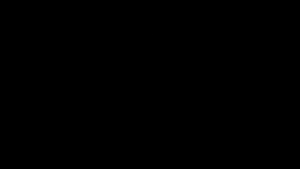


Example: data/masks/cam1_080426_221247.jpg (720, 1280)


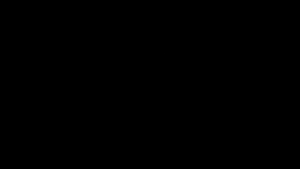

In [8]:
# Sélectionner les lignes où 'center_point' n'est pas None et les masques ont probablement été créés
df_with_masks = df[df['center_point'].notna()]

sampled_masks = df_with_masks.sample(2)

print(f"Displaying {2} segmentation masks:")

# En supposant que 'mask_path' est déjà défini à partir de la cellule précédente
# Si 'mask_path' n'est pas défini, il peut être nécessaire de le redéfinir ici : mask_path = Path('data/masks/')

for index, row in sampled_masks.iterrows():
    mask_filename = row['ID']
    mask_file_path = mask_path/mask_filename
    if mask_file_path.exists():
        im = PILImage.create(mask_file_path)
        print(f"\nExample: {mask_file_path} {im.shape}")
        display(im.to_thumb(300))
    else:
        print(f"Mask file not found for {mask_filename}")

### Dataloader `get` Functions

In [9]:
def get_x(dataframe_row):
    return dataset_path/f"{dataframe_row['ID']}"

def get_mask(dataframe_row):
    return mask_path/f"{dataframe_row['ID']}"

### Create val, train and test data



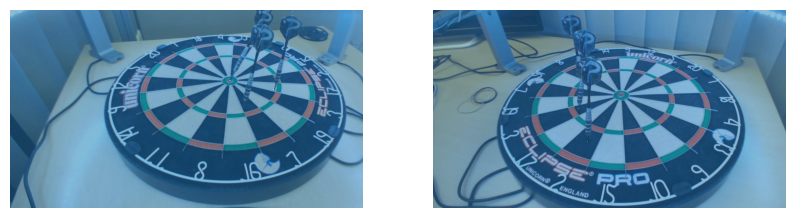

In [10]:
# Sur 300 images :
# 220 (~73,3%) pour train
# 40 (~13,3%) pour val
# 40 (~13,3%) pour val

# Séparer les données de test
df_trainval, df_test = train_test_split(df, test_size=40, random_state=42, shuffle=True)

# Séparer les données d'entraînement et de validation
df_train, df_val = train_test_split(
    df_trainval,
    test_size=40,
    random_state=42,
    shuffle=True
)

# Créer les indices pour les données de validation pour avoir exactement 40 images
# Ne pas utiliser RandomSplitter car valid_pct = 0.13333... et c'est ambigu -> Soit 39 ou 41 images
df_trainval = pd.concat([df_train, df_val])
valid_idx = list(range(len(df_train), len(df_trainval))) # De l'indice 220 à 259 (40 images)

# Transformations
tfms = [Rotate(), Zoom(), Warp(), Brightness(), Flip(), Contrast(), Normalize.from_stats(*imagenet_stats)]

# Entraînement / Validation avec RandomSplitter
d_unet = DataBlock(blocks=(ImageBlock, MaskBlock),
                 get_x=get_x,
                 get_y=get_mask,
                 splitter=IndexSplitter(valid_idx),
                 batch_tfms=tfms)

# La taille du lot est passée dans le dataloader
# Attention à l'overfitting et à l'utilisation excessive de la mémoire GPU
BATCH_SIZE = 2 # Réduit de 2 à 1 pour éviter une erreur de mémoire insuffisante
# dls pour DataLoaders
dls = d_unet.dataloaders(df_trainval, bs=BATCH_SIZE)
dls.show_batch(max_n=2, figsize=(10,10))

### Custom Accuracy Metrics

In [13]:
def accuracy_camvid(inp, targ):
  targ = targ.squeeze(1)
  mask = targ != void_code
  return (inp.argmax(dim=1)[mask]==targ[mask]).float().mean()

name2id = {'Background': 0, 'Point': 1, 'Void': 2}
void_code = name2id['Void']

### Create `UNet` Learner

In [2]:
# Initialisation du modèle
# > construit le modèle U-Net prêt à être entraîné

learn = unet_learner(dls=dls, arch=resnet34, metrics=accuracy_camvid, self_attention=True, act_cls=Mish, pretrained=True, blur_final=True,
                     opt_func=ranger, n_out=2)

NameError: name 'unet_learner' is not defined

### Training Model

<div></div>

le bon pas d'apprentissage (lr) 2.511886486900039e-05
CPU times: user 1min 20s, sys: 926 ms, total: 1min 21s
Wall time: 1min 25s


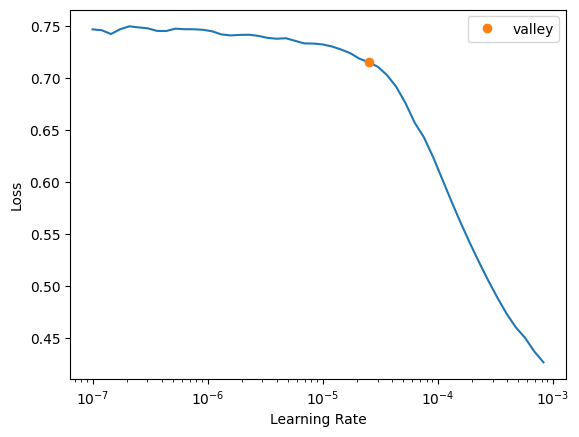

In [16]:
%%time
# Résumé du modèle (architecture, couche, nb paramètres, ...)
# learn.summary()

# Activer l'entraînement en précision mixte pour réduire la consommation de mémoire GPU
learn.to_fp16()

# Détermine le bon learning_rate via un learning rate finder
lr = learn.lr_find().valley
print("le bon pas d'apprentissage (lr)",lr)

In [ ]:
# Lancer l'entraînement du modèle
# lr=1e-3 # taux d'apprentissage
wd=1e-2 # weight decay
EPOCHS = 4

early_stopping_callback = EarlyStoppingCallback(monitor="valid_loss", patience=1)
checkpoint_callback = SaveModelCallback(
    monitor="valid_loss",
    fname="best_model", # Le meilleur modèle sera enregistré dans ce fichier et chargé à la fin de l'entraînement
)

# fit one cycle ajuste dynamiquement le taux d'apprentissage entre une valeur basse et maximale tout au long de l'entraînement
learn.fit_one_cycle(
    EPOCHS,
    slice(lr),
    pct_start=0.9, # 90% du temps d'entraînement à augmenter lr
    wd=wd,
    cbs=[
        early_stopping_callback,
        checkpoint_callback,
        WandbCallback()
    ]
)

epoch,train_loss,valid_loss,accuracy_camvid,time
0,0.441200,0.073878,0.990044,02:03
1,0.049558,0.002909,0.999797,02:04
2,0.006832,0.001409,0.999953,01:58
3,0.001609,0.000910,0.999956,01:58


Better model found at epoch 0 with valid_loss value: 0.07387824356555939.
Better model found at epoch 1 with valid_loss value: 0.0029085567221045494.
Better model found at epoch 2 with valid_loss value: 0.0014089075848460197.
Better model found at epoch 3 with valid_loss value: 0.0009099667659029365.


### Enregistrer le modèle

In [18]:
# learn.save('dartsify_ai')
# !cp "models/dartsify_ai.pth" "drive/My Drive/Dartsify/models/"

### Afficher les résultats

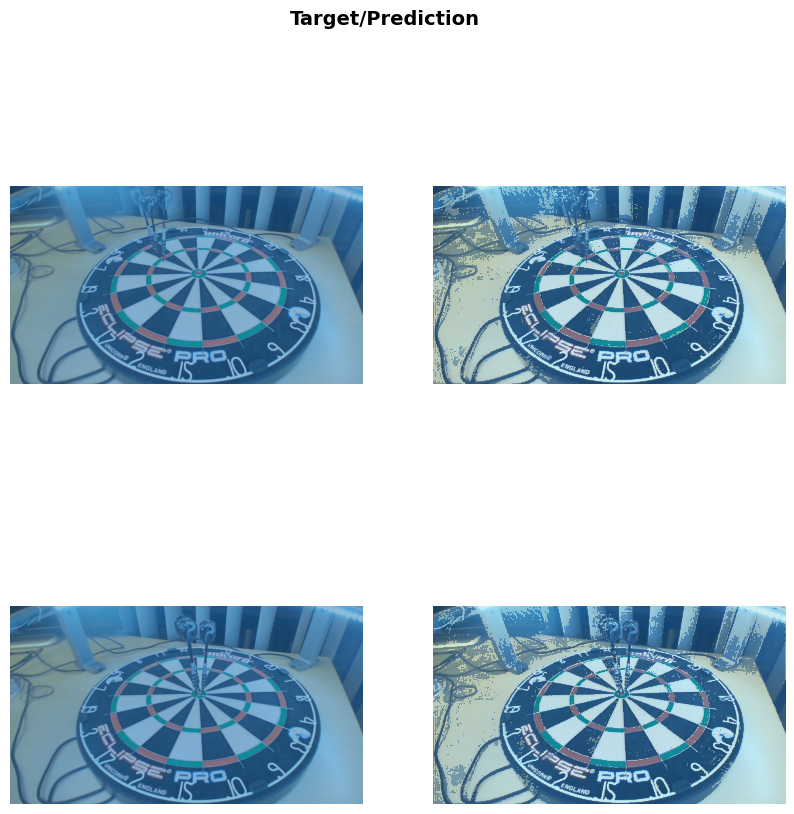

In [32]:
learn.show_results(ds_idx=1, max_n=12, figsize=(10,10))

### Exporter/Importer le modèle


In [43]:
learn.export()

In [46]:
%cp export.pkl "drive/My Drive/Dartsify/models/dartsify_ai.pkl"

### Code d'inférence pour charger et tester le modèle

In [47]:
learn_inf = load_learner("drive/My Drive/Dartsify/models/dartsify_ai.pkl")

/usr/local/lib/python3.12/dist-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


In [50]:
%%time
out = learn_inf.predict('data/dataset/cam1_080426_221128.jpg')

CPU times: user 21.3 s, sys: 4.38 s, total: 25.6 s
Wall time: 25.9 s


In [58]:
%%time
image = cv2.imread('data/dataset/cam1_080426_221128.jpg', cv2.IMREAD_COLOR)

img = image[:, :, ::-1].copy()
img_out = out[0].numpy()
img_out = cv2.convertScaleAbs(img_out)

# Trouver les contours de l'image
contours = cv2.findContours(img_out, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
contours = imutils.grab_contours(contours)

for c in contours:
    M = cv2.moments(c)
    # Vérifier si m00 (surface) n'est pas zéro pour éviter une erreur de division par zéro

    cX = int(M["m10"] / M["m00"])
    cY = int(M["m01"] / M["m00"])
    print("La pointe se trouve en zéro:", (cX, cY))

    img = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)

    # Couche de transparence
    overlay = img.copy()
    output = img.copy()
    inner_colour = (255, 255, 255)
    outer_colour = (255, 255, 255)
    cv2.circle(overlay, (cX, cY), 25, outer_colour, -1)
    alpha = 0.2
    cv2.addWeighted(overlay, alpha, output, 1 - alpha,0, output)

    # Pointe de fléchette
    cv2.circle(output, (cX, cY), 25, outer_colour, 1, cv2.LINE_AA)
    cv2.circle(output, (cX, cY), 3, inner_colour, 1, cv2.LINE_AA)
    #cv2.putText(output, f"{(cX, cY)}", (cX - 105, cY - 30), cv2.FONT_HERSHEY_SIMPLEX,
    #            0.5, inner_colour, 1, cv2.LINE_AA)

plt.figure(figsize = (14, 14))
plt.imshow(output)
plt.show()

La pointe se trouve en zéro: (1179, 716)
La pointe se trouve en zéro: (1170, 714)
La pointe se trouve en zéro: (1169, 716)


ZeroDivisionError: float division by zero